# LU Factorization:

### a.) Implementation of LU Factorization and Substitution:

In [134]:
import numpy as np
def lu_factorization(A,tol=1e-12):
    n = A.shape[0]
    L = np.zeros((n, n))
    U = A.copy().astype(float)
    P = np.eye(n)
    
    for i in range(n):                     #loop through number of A rows ..
        pivot = None                       # Choose the first row r (i <= r < n) with a nonzero pivot
        for r in range(i, n):              # Loop through columns for upper triangular matrix U
            if abs(U[r, i]) > tol:
                pivot = r
                break

        
        if pivot != i:                      # Swap row i with row 'pivot' in U, P, and in L (only columns before i)
            U[[i, pivot]] = U[[pivot, i]]
            P[[i, pivot]] = P[[pivot, i]]
            if i > 0:
                L[[i, pivot], :i] = L[[pivot, i], :i]  
        L[i, i] = 1.0                          # The diagonal elements of L are 1

        
        for j in range(i+1, n):                # Eliminate entries below the pivot
            L[j, i] = U[j, i] / U[i, i] 
            U[j, :] -= L[j, i] * U[i, :]
    
    return P, L, U

In [135]:
def forward_substitution(L, b):
    """
    Holds the same consept from above for forward substitution but we solve for Solve Ux = y
    """
    n = L.shape[0]                             # get the size of L
    y = np.zeros(n)                            # creates matrix y same size of a with 0's
    for i in range(n):                         # Loop through each row
        y[i] = b[i] - np.dot(L[i, :i], y[:i])  # Solve for y[i] by subtracting contributions of previous y's
    return y                                   # Return y

def backward_substitution(U, y):
    """
    Solve Ux = y for x using backward substitution.
    """
    n = U.shape[0]                             # get the size of L
    x = np.zeros(n)                            # creates matrix xL same size of a with 0's
    for i in reversed(range(n)):               # Loop through each row in reverse order
        x[i] = (y[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]  # Solve for x[i] by subtracting contributions of previously solved x's
    return x                                   # Return x

### b.) Solving a System of Linear Equations:

In [183]:
# test Q3 a.) and b.)
import time
A = np.array([[0, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)
b = np.array([1, 2, 3], dtype=float)

# Solve using the modified LU routines with partial pivoting:
start_custom = time.time()        # track the time for later
x = solve_lu(A, b)
P, L, U = lu_factorization(A)
L, U = lu_factorization2(A)
end_custom = time.time()
print("Lower triangular matrix L =\n", L)
print("Upper triangular matrix U =\n", U)
print("Solution x =", x)

Lower triangular matrix L =
 [[1.         0.         0.        ]
 [0.57142857 1.         0.        ]
 [0.         4.66666667 1.        ]]
Upper triangular matrix U =
 [[ 7.          8.          9.        ]
 [ 0.          0.42857143  0.85714286]
 [ 0.          0.         -1.        ]]
Solution x = [0.         0.         0.33333333]


In [136]:
def solve_lu(A, b):
    """
    Solve Ax = b using helper from above lu_factorization and substitutionsa.
    """
    P, L, U = lu_factorization(A)
    b_permuted = P @ b  # Permute the right-hand side
    y = forward_substitution(L, b_permuted)
    x = backward_substitution(U, y)
    return x

### c.) Comparison with Python Built-in Functions

In [184]:
# Part (c): Solve using built-in scipy functions.
import scipy.linalg
start_scipy = time.time()
P, L_scipy, U_scipy = scipy.linalg.lu(A)
x_scipy = scipy.linalg.solve(A, b)
end_scipy = time.time()
print("Using scipy.linalg.lu and la.solve:")
print("L (scipy) =\n", L_scipy)
print("U (scipy) =\n", U_scipy)
print("Solution x =", x_scipy)

print("Custom LU time: ", end_custom - start_custom)
print("SciPy LU time: ", end_scipy - start_scipy)

Using scipy.linalg.lu and la.solve:
L (scipy) =
 [[1.         0.         0.        ]
 [0.         1.         0.        ]
 [0.57142857 0.21428571 1.        ]]
U (scipy) =
 [[7.         8.         9.        ]
 [0.         2.         3.        ]
 [0.         0.         0.21428571]]
Solution x = [-1.01506105e-15 -4.00000000e+00  3.66666667e+00]
Custom LU time:  0.08732771873474121
SciPy LU time:  0.0010030269622802734


In [188]:
# iv. The results from both the custom LU implementation and SciPy’s built-in functions are similar  [very small numerical errors (~10^-16),]
# v. SciPy is slightly slower due to the overhead of optimized routines and additional checks, but when its a larger matrices SciPy’s  will outperforms my implementation 

### d.) Complexity Analysis

In [189]:
# Q3(d): Complexity Analysis
def generate_random_nonsingular_matrix(n):
    while True:
        A = np.random.uniform(0, 100, size=(n, n))
        if np.linalg.matrix_rank(A) == n:
            return A

def random_system(n):
    A = generate_random_nonsingular_matrix(n)
    b = np.random.uniform(0, 100, size=n)
    return A, b


In [194]:
import matplotlib.pyplot as plt

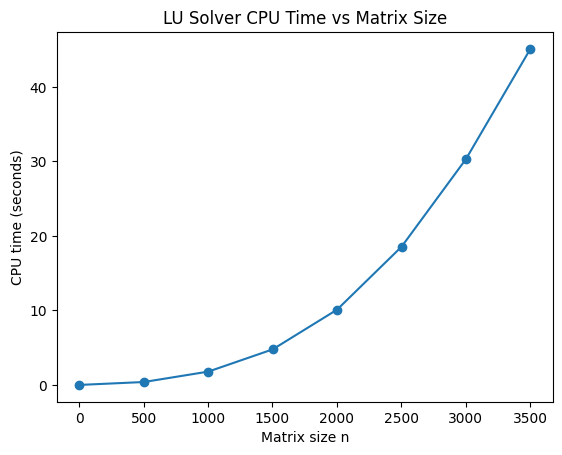

In [198]:
sizes = range(2, 4001, 500)
times_list = []
for n in sizes:
    A_rand, b_rand = random_system(n)
    start = time.time()
    x_rand = solve_lu(A_rand, b_rand)
    times_list.append(time.time() - start)

plt.figure()
plt.plot(list(sizes), times_list, 'o-')
plt.xlabel('Matrix size n')
plt.ylabel('CPU time (seconds)')
plt.title('LU Solver CPU Time vs Matrix Size')
plt.show()

In [199]:
# Bonus: Polynomial (power law) fit (quadratic fit used for demonstration)

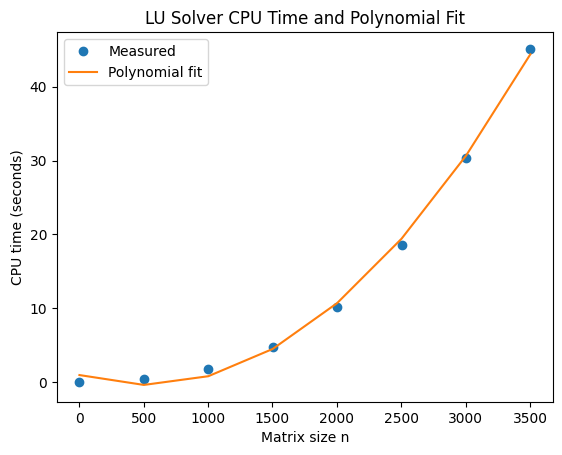

In [200]:
coeffs = np.polyfit(np.array(list(sizes)), times_list, 2)   # Fit a 2nd degree polynomial
fit_times = np.polyval(coeffs, np.array(list(sizes)))         # Evaluate the polynomial at the given sizes
plt.figure()   
plt.plot(list(sizes), times_list, 'o', label='Measured')      # Plot the measured times as scatter points
plt.plot(list(sizes), fit_times, '-', label='Polynomial fit') # Plot the polynomial fit as a line
plt.xlabel('Matrix size n')
plt.ylabel('CPU time (seconds)')
plt.legend()
plt.title('LU Solver CPU Time and Polynomial Fit')
plt.show()

In [ ]:
#The graph align well with the theoretical complexity O(n³) for LU factorization. LU factorization is 
# ...efficient for moderate-sized systems (n < 500), the will explatialy increase in time as seen above.